## Introduction
This project will be looking into analyzing the data from OKcupid, an app that focuses on using multiple choice and short answers to match users. In recent years, there has been a massive rise in the usage of dating apps to find love. Many of these apps use sophisticated data science techniques to recommend possible matches to users and to optimize the user experience. These apps give us access to a wealth of information that we’ve never had before about how different people experience romance.

The data `profiles.csv` was provided from codecademy.com .

## Scoping
The scope of this project will be to look into the data we have to analyze and display useful information from the columns, as well as make use of machine learning techniques to attempt to make predictions based on the data. 

### Project Goals
Our goals are simple. We want to analyze the data, Display useful information about the data and make predictions with Machine Learning based on the data.

### Data
Our data `profiles.csv` was provided by codecademy.com. each row in the data represents a user details and inputs from the multiple choice questions. 

### Analysis
This solution will use descriptive statistics and data visualization techniques, to find key figures in understanding the distribution, count, and relationship between the variables. The goal of this project is to make **predictions of a person's sex**. We will be making use of Binary Classification models, such as:
- Logistic regression
- K-Nearest Neighbors
- Random Forest Classifier.

### Evaluation
The project will conclude with the evaluation of the machine learning model selected with a validation data set. The output of the predictions can be checked through a confusion matrix, and metrics such as accuracy, precision, recall, F1-scores.


### Importing our Python Modules

In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
### Load the data into your work space
df = pd.read_csv('profiles.csv')
df.head()

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38,thin,anything,socially,NaN,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,...,"san francisco, california",NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available
3,23,thin,vegetarian,socially,NaN,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,...,"berkeley, california",doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single
4,29,athletic,NaN,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at:<br />\nhttp://bag...,i smile a lot and my inquisitive nature,...,"san francisco, california",NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single


In [66]:
### Analyze the data with info/describe descriptions.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   body_type    54650 non-null  object 
 2   diet         35551 non-null  object 
 3   drinks       56961 non-null  object 
 4   drugs        45866 non-null  object 
 5   education    53318 non-null  object 
 6   essay0       54458 non-null  object 
 7   essay1       52374 non-null  object 
 8   essay2       50308 non-null  object 
 9   essay3       48470 non-null  object 
 10  essay4       49409 non-null  object 
 11  essay5       49096 non-null  object 
 12  essay6       46175 non-null  object 
 13  essay7       47495 non-null  object 
 14  essay8       40721 non-null  object 
 15  essay9       47343 non-null  object 
 16  ethnicity    54266 non-null  object 
 17  height       59943 non-null  float64
 18  income       59946 non-null  int64  
 19  job 

In [67]:
print(df.describe())

                age        height          income
count  59946.000000  59943.000000    59946.000000
mean      32.340290     68.295281    20033.222534
std        9.452779      3.994803    97346.192104
min       18.000000      1.000000       -1.000000
25%       26.000000     66.000000       -1.000000
50%       30.000000     68.000000       -1.000000
75%       37.000000     71.000000       -1.000000
max      110.000000     95.000000  1000000.000000


In [68]:
### Plot Hitsplots of the various columns.

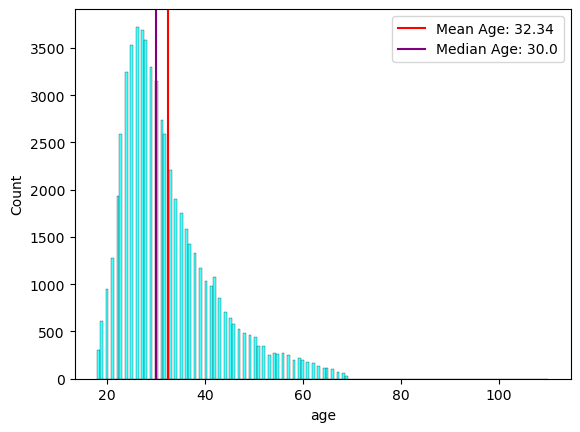

In [69]:
age = df.age.dropna()
age = age[age != '']
mean_age = np.mean(age)
median_age = np.median(age)
sns.histplot(age, color = 'cyan')
plt.axvline(mean_age, color = 'red', label='Mean Age: '+ str(mean_age.round(2)))
plt.axvline(median_age, color = 'purple', label='Median Age: '+ str(median_age.round(2)))
plt.legend()
plt.show()

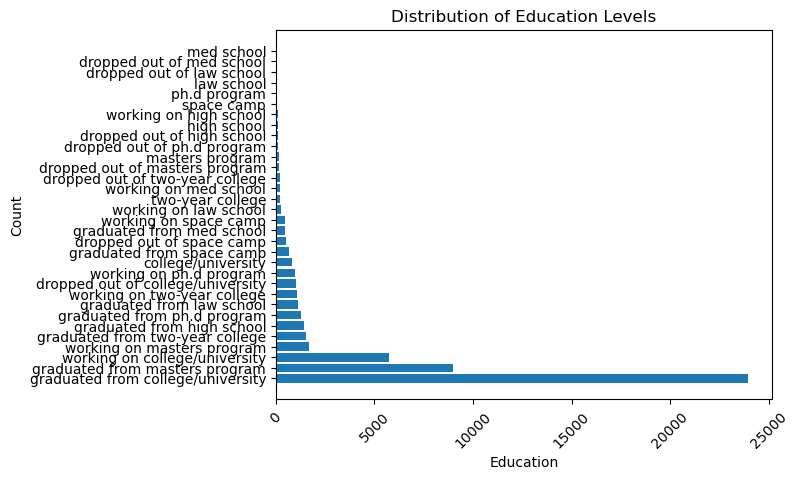

In [70]:
education = df.education.dropna()       # remove NaN
education = education[education != '']  # remove empty strings

counts = education.value_counts()

plt.barh(counts.index, counts.values)
plt.xticks(rotation=45)
plt.xlabel("Education")
plt.ylabel("Count")
plt.title("Distribution of Education Levels")
plt.show()

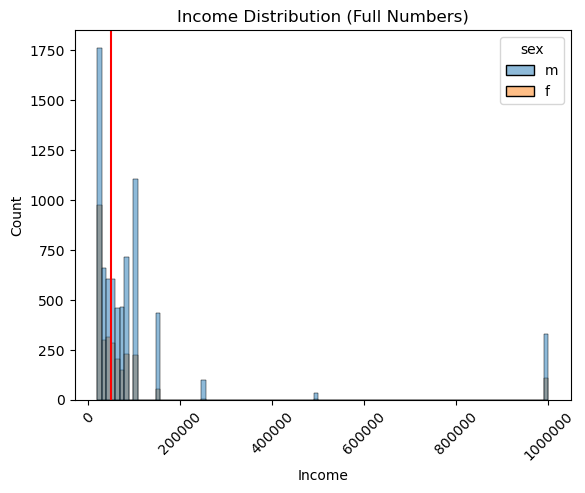

In [71]:
income = df.income.dropna()
income = income[income != -1]
#sns.histplot(income, bins = 60)
#mean_income = np.mean(income) ## not very useful. so we will make use of the Median Income.
median_income = np.median(income) ## Showing our median income on the chart.
#plt.axvline(mean_income, color = 'red', label='Mean Income: ' + str(mean_income.round(2)))
#plt.axvline(median_income, color = 'green', label='Median Income: '+ str(median_income))
#plt.ticklabel_format(style='plain', axis='x')
#plt.xlabel("Income")
#plt.ylabel("Count")
#plt.title("Income Distribution (Full Numbers)")
#plt.legend()
##plt.show()

# Align the other column (e.g., 'sex') to match clean_sign
clean_sign = df['sign'].dropna().str.split().str[0]
clean_df = pd.DataFrame({
    'income': income,
    'sex': df.loc[clean_sign.index, 'sex']  # select same indices
})

sns.histplot(data = clean_df, x = 'income', hue = 'sex', bins = 100, edgecolor='black')
plt.ticklabel_format(style='plain', axis='x')
plt.axvline(median_income, color = 'red', label='Median Income: '+ str(median_income))
plt.xlabel("Income")
plt.ylabel("Count")
plt.title("Income Distribution (Full Numbers)")
#plt.legend()
plt.xticks(rotation=45)
plt.show()

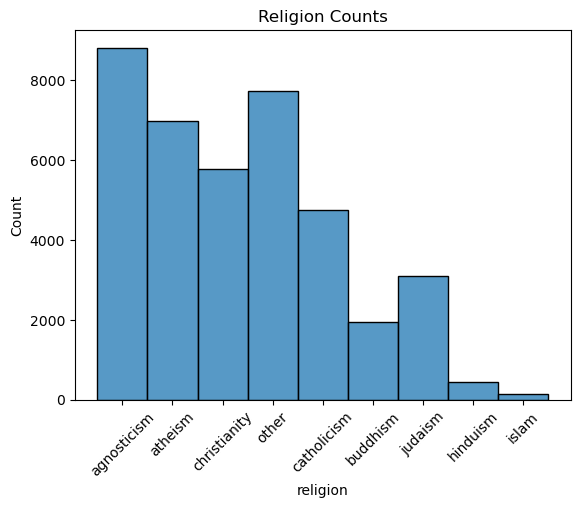

In [72]:
religion = df.religion.dropna()
first_words = religion.str.split().str[0]
sns.histplot(first_words)
plt.xticks(rotation=45)
plt.title('Religion Counts')
#plt.legend()
plt.show()

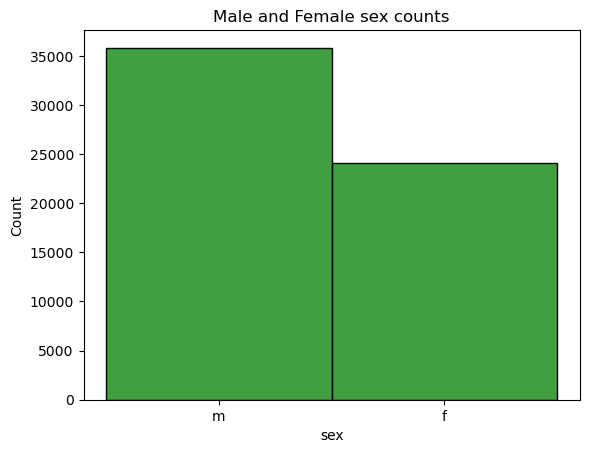

In [73]:
sns.histplot(df.sex, color='green', edgecolor='black')
plt.title('Male and Female sex counts')
plt.show()

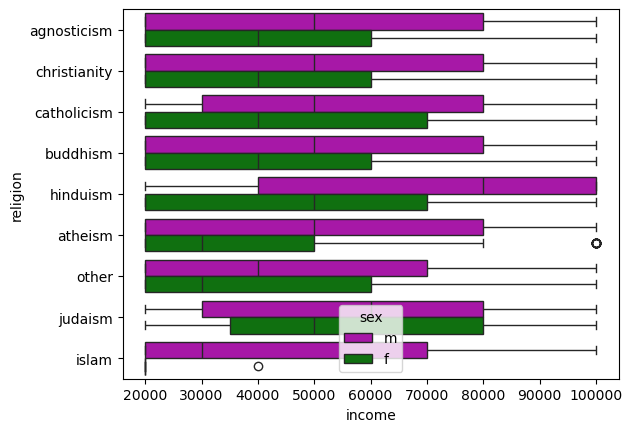

In [74]:
## focusing only on the bottom 75% of earners to filter out outliers and make the data more readable.
sex = df.sex.dropna()
clean_df = pd.DataFrame({'income': income, 'religion': first_words, 'sex': sex })

p75 = clean_df['income'].quantile(0.75)

# Keep only rows with income <= 75th percentile
bottom_75_df = clean_df[clean_df['income'] <= p75]

sns.boxplot(x="income", y="religion", hue="sex", palette=["m", "g"], data=bottom_75_df)
plt.show()

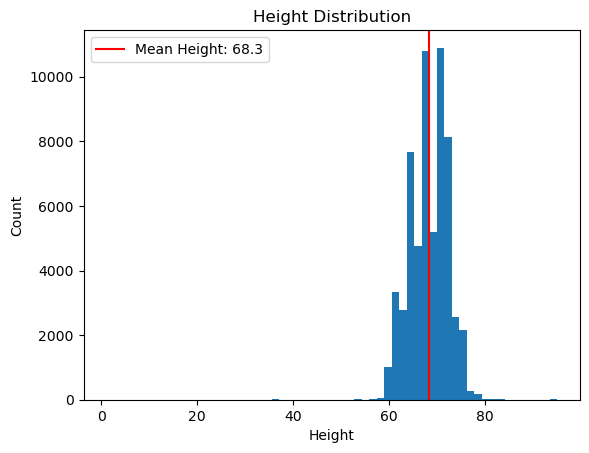

In [75]:
plt.hist(df.height, bins = 60)
plt.xlabel('Height')
plt.ylabel('Count')
plt.title('Height Distribution')
mean_height = np.mean(df.height)
plt.axvline(mean_height, color ='red',label = "Mean Height: "+ str(mean_height.round(2))) ## Marking the mean height.
plt.legend()
plt.show()

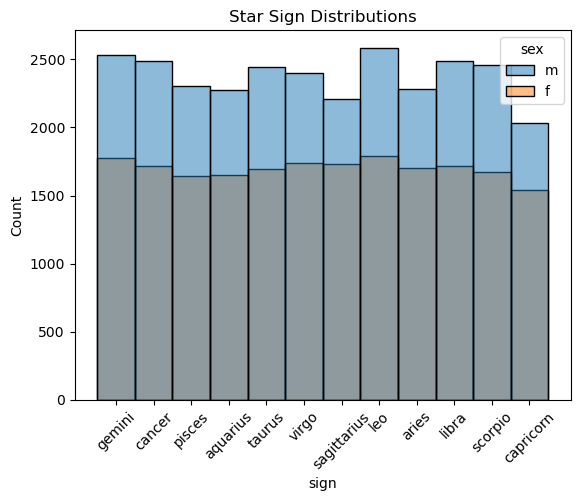

In [76]:
# Drop NaNs from 'sign' and get first word
clean_sign = df['sign'].dropna().str.split().str[0]

# Align the other column (e.g., 'sex') to match clean_sign
clean_df = pd.DataFrame({
    'sign': clean_sign,
    'sex': df.loc[clean_sign.index, 'sex']  # select same indices
})

sns.histplot(data = clean_df, x = 'sign', hue = 'sex')
plt.title('Star Sign Distributions')
plt.xticks(rotation=45)
plt.show()

### Separating our Data, to Select our useful features for Principal Component Analysis and Machine Learning.

In [77]:
print(df.columns)

Index(['age', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'essay0',
       'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7',
       'essay8', 'essay9', 'ethnicity', 'height', 'income', 'job',
       'last_online', 'location', 'offspring', 'orientation', 'pets',
       'religion', 'sex', 'sign', 'smokes', 'speaks', 'status'],
      dtype='object')


We have selected the Features we wish to narrow down and make our predictions.
Age, body type, diet, drinks, drugs, height, income, sign and smokes. Our target Feature, is sex.

In [78]:
cols_needed = ['age', 'body_type', 'diet', 'drinks', 'drugs', 
               'height', 'income', 'sign', 'smokes', 'sex']

df_clean = df[cols_needed].dropna()  # remove any row with missing value in these columns

# Now X and y have the same number of rows
X = df_clean[['age', 'body_type', 'diet', 'drinks','drugs','height', 'income', 'sign', 'smokes']]
y = df_clean['sex']

We are going to start preprocessing our Features, as we will need them to be ready for the Principal Component Analysis stage.

In [79]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = ['body_type', 'diet', 'drinks', 'drugs', 'sign', 'smokes']
numeric_cols = ['age', 'height', 'income']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

X_preprocessed = preprocessor.fit_transform(X)

#### Now we are going to perform the Principal Component Analysis (PCA) on our data.

In [80]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_preprocessed)

#### We are now going to seperate our data into the Training Set and Testing sets.

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape) ## Will print out the number of samples/rows and the number of columns/features after performing our prepocessing.
print(X_test.shape, y_test.shape)

(17324, 89) (17324,)
(4331, 89) (4331,)


### Running our Logistic Regression Model to predict the `Sex`

In [82]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

log_y_pred = logreg.predict(X_test)

 #### Now we have trained our model and made our predictions, we will now look into evaulating our model.

Accuracy: 0.8681597783421843
Precision: 0.8833652007648184
Recall: 0.8967391304347826
F1 Score: 0.8900019264110961
              precision    recall  f1-score   support

           f       0.84      0.83      0.84      1755
           m       0.88      0.90      0.89      2576

    accuracy                           0.87      4331
   macro avg       0.86      0.86      0.86      4331
weighted avg       0.87      0.87      0.87      4331



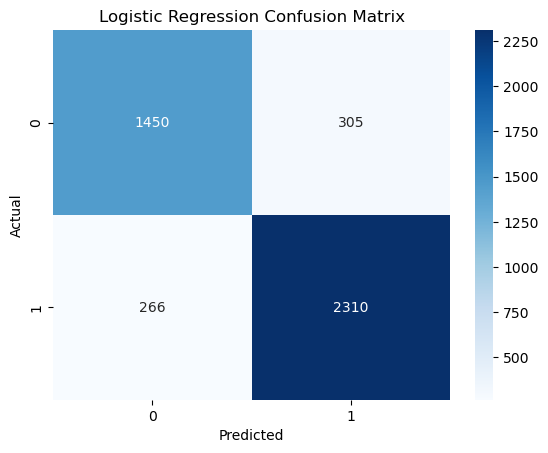

In [83]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Viewing our model's accuracy score. 
log_accuracy =  accuracy_score(y_test, log_y_pred)
print("Accuracy:", accuracy_score(y_test, log_y_pred))
print("Precision:", precision_score(y_test, log_y_pred, pos_label='m'))
print("Recall:", recall_score(y_test, log_y_pred, pos_label='m'))
print("F1 Score:", f1_score(y_test, log_y_pred, pos_label='m'))

# Detailed metrics
print(classification_report(y_test, log_y_pred))

# Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, log_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

### Now, using K Nearest Neighbors to predict the `Sex`

In [84]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)  # you can tune n_neighbors later
# Fit KNN on the training data
knn.fit(X_train, y_train)

KNeighborsClassifier()

### We have now created and trained our model on the data, let us now make our predictions on the Test set

In [85]:
# Predict on test set
knn_y_pred = knn.predict(X_test)

### Let us now evaluate our Model's prediction:

Accuracy: 0.8298314477026091
Precision: 0.8439955106621774
Recall: 0.8757763975155279
F1 Score: 0.8595923032958659
              precision    recall  f1-score   support

           f       0.81      0.76      0.78      1755
           m       0.84      0.88      0.86      2576

    accuracy                           0.83      4331
   macro avg       0.83      0.82      0.82      4331
weighted avg       0.83      0.83      0.83      4331



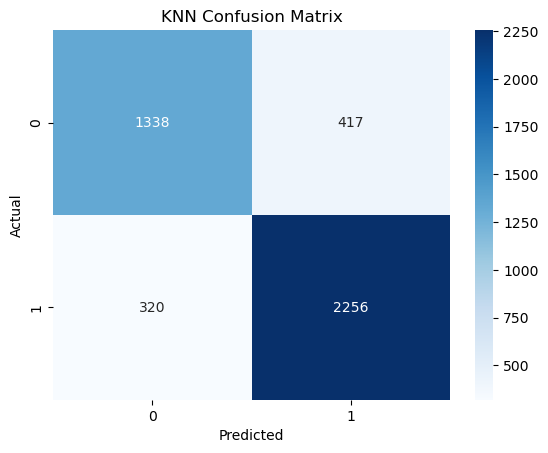

In [86]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Viewing our model's accuracy score.
print("Accuracy:", accuracy_score(y_test, knn_y_pred))
print("Precision:", precision_score(y_test, knn_y_pred, pos_label='m'))
print("Recall:", recall_score(y_test, knn_y_pred, pos_label='m'))
print("F1 Score:", f1_score(y_test, knn_y_pred, pos_label='m'))

# Detailed metrics
print(classification_report(y_test, knn_y_pred))

# Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, knn_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')
plt.show()

#### Attempting to tune our KNearest Neighbors, to get better accuracy.

We got a maximum accuracy of 0.8559224197644886 with a number of neighbors of 15


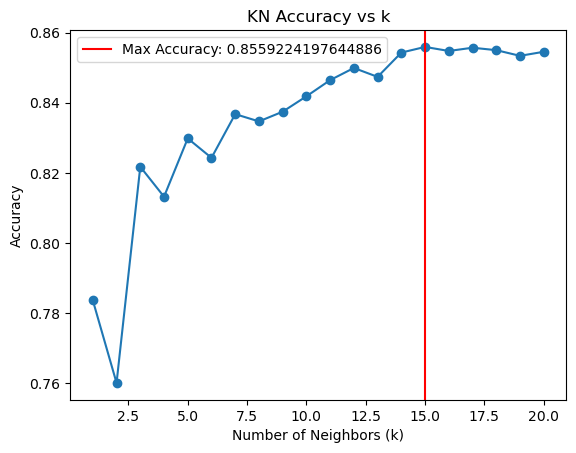

In [106]:
accuracy_list = []
accuracy_parameters = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    knn_y_pred = knn.predict(X_test)
    accuracy_list.append(accuracy_score(y_test, knn_y_pred))

knn_accuracy = np.max(accuracy_list)
max_k = accuracy_list.index(max(accuracy_list))
print("We got a maximum accuracy of " + str(np.max(accuracy_list)) + " with a number of neighbors of " + str(max_k+1))
plt.plot(range(1, 21), accuracy_list, marker='o')
plt.axvline(max_k+1, color ='red',label = "Max Accuracy: "+ str(max(accuracy_list)))
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KN Accuracy vs k')
plt.legend()
plt.show()


### Now we are going to use our final Machine Learning Model, Random Forest classifier.

In [88]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
rf = RandomForestClassifier(
    n_estimators=100,       # number of trees
    random_state=42,        # ensures reproducible results
    max_depth=40,         # can limit depth to prevent overfitting
    n_jobs=-1               
)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=40, n_jobs=-1, random_state=42)

Now we have created our Random Forest classifier, and trained it on our Test data, we are now going to make our predictions and evaluate.

In [95]:
rf_y_pred = rf.predict(X_test)

Our preduction has been made, let us now evaluate our results.

Accuracy: 0.8575386746709767
Precision: 0.8765859284890427
Recall: 0.8850931677018633
F1 Score: 0.8808190071469963
              precision    recall  f1-score   support

           f       0.83      0.82      0.82      1755
           m       0.88      0.89      0.88      2576

    accuracy                           0.86      4331
   macro avg       0.85      0.85      0.85      4331
weighted avg       0.86      0.86      0.86      4331



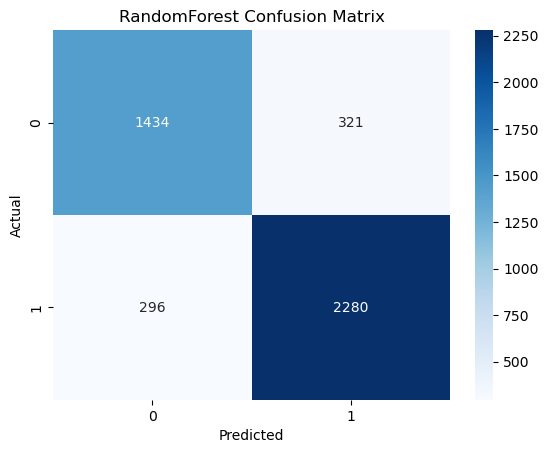

In [96]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Viewing our model's accuracy score. 
rf_accuracy = accuracy_score(y_test, rf_y_pred)
print("Accuracy:", accuracy_score(y_test, rf_y_pred))
print("Precision:", precision_score(y_test, rf_y_pred, pos_label='m'))
print("Recall:", recall_score(y_test, rf_y_pred, pos_label='m'))
print("F1 Score:", f1_score(y_test, rf_y_pred, pos_label='m'))

# Detailed metrics
print(classification_report(y_test, rf_y_pred))

# Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('RandomForest Confusion Matrix')
plt.show()

## Conclusion

We have gone over the data in our `profiles.csv` file and have attempted to make predictions on the sex of our samples based on 9 of our features that we selected. We made use of the Logisitic Regression Model, KNeighbors Classifier and our Random Forest Classifier.

We are going to go over the Accuracy scores our models got, and visualize them.
- Our highest accuracy score came from: Logistic Regression with a score of 0.8681597783421843.
- Our Mean accuracy score was: 0.861, or 86%
- Our lowest accuracy score was: K-Nearest Neigbhors with a score of 0.8559224197644886

All our models performed sub-par, with a project goal of 95%, we were not able to reach it even with tuning the K-Nearest Neigbhors.

0.8605402909258832


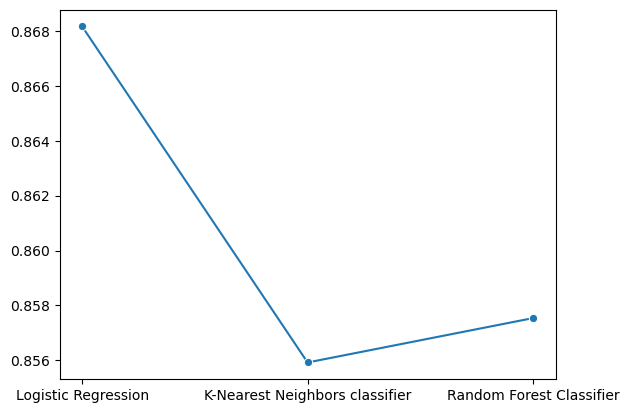

In [107]:
acc_data = [log_accuracy, knn_accuracy, rf_accuracy]
labels = ['Logistic Regression', 'K-Nearest Neighbors classifier', 'Random Forest Classifier']

mean_scores = np.mean(acc_data)
print(mean_scores)
sns.lineplot(x=labels, y=acc_data, marker = 'o')
plt.show()

### Next Steps

If we were to handle this project again, we should surely make use of Neural Networks, as they should theoretically be able to make more accurate predictions on the data, the longer we have them running.